# Import Dependencies & Konfigurasi Project

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim
from skimage.metrics import mean_squared_error as compute_mse

plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 9

In [36]:
# Random seed
np.random.seed(42)

# Logging Config

In [37]:
import logging

class ColorFormatter(logging.Formatter):
    COLORS = {
        'DEBUG': '\033[94m',   # Blue
        'INFO': '\033[92m',    # Green
        'WARNING': '\033[93m', # Yellow
        'ERROR': '\033[91m',   # Red
        'CRITICAL': '\033[1;31m' # Bold Red
    }
    RESET = '\033[0m'

    def format(self, record):
        color = self.COLORS.get(record.levelname, self.RESET)
        record.levelname = f"{color}{record.levelname}{self.RESET}"
        return super().format(record)

# Setup logger
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)

handler = logging.StreamHandler()
handler.setFormatter(ColorFormatter('[%(asctime)s] - %(levelname)s - %(message)s'))
logger.addHandler(handler)

# Loader Image & Generator Noise

In [38]:
def load_or_generate_image(image_path: str = None) -> np.ndarray:
    if image_path:
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            logger.info("Image berhasil dimuat")
            return img
        logger.warning("Image tidak dapat dimuat")

    # Buat linear space dari titik -10 sampe 10 sebanyak 256 titik
    x = np.linspace(-10, 10, 256)
    y = np.linspace(-10, 10, 256)

    xx, yy = np.meshgrid(x, y)

    # Klo nggk ada file lokal bikin image sintetis (256 x 256)
    synthetic: np.ndarray = np.sin(np.sqrt(xx**2 + yy**2)) * 127 + 128

    # Image yang dihasilin bakal kyk circle muter-muter gitu...
    logger.debug("Image sintetis telah berhasil digenerate...")
    return synthetic.astype(np.uint8)

def noise_injector(image: np.ndarray, prob: float = 0.05) -> np.ndarray:
    noisy = image.copy()
    num_salt = np.ceil(prob * image.size * 0.5)
    num_pepper = np.ceil(prob * image.size * 0.5)

    # print(num_salt)
    # print(num_pepper)

    # Salt (noise putih / 255)
    coords = [np.random.randint(0, i-1, int(num_salt)) for i in image.shape]
    noisy[tuple(coords)] = 255

    # Pepper (noise hitam / 0)
    coords = [np.random.randint(0, i-1, int(num_pepper)) for i in image.shape]
    noisy[tuple(coords)] = 0

    # Ngembaliin image setelah di kasih random noise hitam dan putih
    logger.info("Salt & Pepper noise berhasil diterapkan di gambar")
    return noisy

def gaussian_noise_injector(image: np.ndarray, mean: float = 0.0, sigma: float = 25.0) -> np.ndarray:
    gauss = np.random.normal(mean, sigma, image.shape)
    noisy = image.astype(np.float64) + gauss

    # noise di image nya lebih merata
    logger.info("Gaussian Noise berhasil diterapkan ke gambar")
    return np.clip(noisy, 0, 255).astype(np.uint8)

# Data dasar buat eksperimen

In [39]:
# Load image original
original_img = load_or_generate_image("../images/golden-gate.jpg")

# Image original di beri filter noise
salt_pepper_noisy_img = noise_injector(original_img)
gaussian_noisy_img = gaussian_noise_injector(original_img)

[2026-08-16 14:21:56,766] - INFO - Image berhasil dimuat
[2026-08-16 14:21:56,766] - INFO - Image berhasil dimuat
[2026-08-16 14:21:56,768] - INFO - Salt & Pepper noise berhasil diterapkan di gambar
[2026-08-16 14:21:56,768] - INFO - Salt & Pepper noise berhasil diterapkan di gambar
[2026-08-16 14:21:56,780] - INFO - Gaussian Noise berhasil diterapkan ke gambar
[2026-08-16 14:21:56,780] - INFO - Gaussian Noise berhasil diterapkan ke gambar


# Eksperimen terhadap gambar

In [40]:
experiments = []

logger.info("Skenario 1: Evaluasi Median Filter pada Salt-and-Pepper Noise (dengan kernel 3x3, 5x5, 7x7)")

for kern in [3, 5, 7]:
    filtered = cv2.medianBlur(salt_pepper_noisy_img, kern)

    mean_squared_error = compute_mse(original_img, filtered)
    peak_signal_noise_ratio = compute_psnr(original_img, filtered, data_range=255)
    structural_similarity = compute_ssim(original_img, filtered, data_range=255)

    experiments.append({
        "skenario": "Exp-1: Salt & Pepper Noise (prob=0.05)",
        "metode": "Median Filter",
        "parameter": f"Kernel {kern}x{kern}",
        "mse": round(mean_squared_error, 4),
        "psnr": round(peak_signal_noise_ratio, 2),
        "ssim": round(structural_similarity, 4),
        "image": filtered
    })
    logger.debug(f"Experiment Salt & Pepper noise dengan kernel {kern}x{kern} berhasil dilakukan")

logger.info("Skenario 1 Selesai")

logger.info("Skenario 2: Evaluasi Gaussian Filter pada Gaussian Noise (dengan kernel 3x3, 5x5, 7x7)")

for kern in [3, 5, 7]:
    filtered = cv2.GaussianBlur(gaussian_noisy_img, (kern, kern), sigmaX=1.5)

    mean_squared_error = compute_mse(original_img, filtered)
    peak_signal_noise_ratio = compute_psnr(original_img, filtered, data_range=255)
    structural_similarity = compute_ssim(original_img, filtered, data_range=255)

    experiments.append({
        "skenario": "Exp-2: Gaussian Noise (dengan sigma = 25.0)",
        "metode": "Gaussian Filter",
        "parameter": f"Kernel {kern}x{kern}",
        "mse": round(mean_squared_error, 4),
        "psnr": round(peak_signal_noise_ratio, 2),
        "ssim": round(structural_similarity, 4),
        "image": filtered
    })
    logger.debug(f"Experiment Gaussian noise dengan kernel {kern}x{kern} berhasil dilakukan")

logger.info("Skenario 2 Selesai")

logger.info("Skenario 3: Cross-Method Stress Test (Menerapkan Gaussian Filter pada Salt & Pepper Noise)")

for kern in [3, 5, 7]:
    filtered = cv2.GaussianBlur(salt_pepper_noisy_img, (kern, kern), sigmaX=1.5)

    mean_squared_error = compute_mse(original_img, filtered)
    peak_signal_noise_ratio = compute_psnr(original_img, filtered, data_range=255)
    structural_similarity = compute_ssim(original_img, filtered, data_range=255)

    experiments.append({
        "skenario": "Exp-3: Salt & Pepper Noise (Mismatch Test)",
        "metode": "Gaussian Filter (Linear)",
        "parameter": f"Kernel {kern}x{kern}",
        "mse": round(mean_squared_error, 4),
        "psnr": round(peak_signal_noise_ratio, 2),
        "ssim": round(structural_similarity, 4),
        "image": filtered
    })
    logger.debug(f"Experiment Cross-Method Stress Test (Menerapkan Gaussian Filter pada Salt & Pepper Noise) dengan kernel {kern}x{kern} berhasil dilakukan")

logger.info("Skenario 3 Selesai")
logger.info("Experiment Selesai...")

df_results = pd.DataFrame(experiments)

# Table hasil eksperiment
display(df_results[["skenario", "metode", "parameter", "mse", "psnr", "ssim"]])

[2026-08-16 14:21:57,066] - INFO - Skenario 1: Evaluasi Median Filter pada Salt-and-Pepper Noise (dengan kernel 3x3, 5x5, 7x7)
[2026-08-16 14:21:57,066] - INFO - Skenario 1: Evaluasi Median Filter pada Salt-and-Pepper Noise (dengan kernel 3x3, 5x5, 7x7)
[2026-08-16 14:21:57,102] - DEBUG - Experiment Salt & Pepper noise dengan kernel 3x3 berhasil dilakukan
[2026-08-16 14:21:57,102] - DEBUG - Experiment Salt & Pepper noise dengan kernel 3x3 berhasil dilakukan
[2026-08-16 14:21:57,139] - DEBUG - Experiment Salt & Pepper noise dengan kernel 5x5 berhasil dilakukan
[2026-08-16 14:21:57,139] - DEBUG - Experiment Salt & Pepper noise dengan kernel 5x5 berhasil dilakukan
[2026-08-16 14:21:57,186] - DEBUG - Experiment Salt & Pepper noise dengan kernel 7x7 berhasil dilakukan
[2026-08-16 14:21:57,186] - DEBUG - Experiment Salt & Pepper noise dengan kernel 7x7 berhasil dilakukan
[2026-08-16 14:21:57,187] - INFO - Skenario 1 Selesai
[2026-08-16 14:21:57,187] - INFO - Skenario 1 Selesai
[2026-08-16 14

,skenario,metode,parameter,mse,psnr,ssim
0,Exp-1: Salt & Pepper Noise (prob=0.05),Median Filter,Kernel 3x3,38.8682,32.23,0.9417
1,Exp-1: Salt & Pepper Noise (prob=0.05),Median Filter,Kernel 5x5,85.0216,28.84,0.8707
2,Exp-1: Salt & Pepper Noise (prob=0.05),Median Filter,Kernel 7x7,117.3471,27.44,0.8274
3,Exp-2: Gaussian Noise (dengan sigma = 25.0),Gaussian Filter,Kernel 3x3,113.3128,27.59,0.6138
4,Exp-2: Gaussian Noise (dengan sigma = 25.0),Gaussian Filter,Kernel 5x5,107.3657,27.82,0.7229
5,Exp-2: Gaussian Noise (dengan sigma = 25.0),Gaussian Filter,Kernel 7x7,109.9372,27.72,0.7480
6,Exp-3: Salt & Pepper Noise (Mismatch Test),Gaussian Filter (Linear),Kernel 3x3,158.2346,26.14,0.5692
7,Exp-3: Salt & Pepper Noise (Mismatch Test),Gaussian Filter (Linear),Kernel 5x5,130.7432,26.97,0.6807
8,Exp-3: Salt & Pepper Noise (Mismatch Test),Gaussian Filter (Linear),Kernel 7x7,129.5879,27.01,0.7115


In [41]:
# Buat Table Latex
latex_table = df_results[["skenario", "metode", "parameter", "mse", "psnr", "ssim"]].to_latex(index=False, caption="Quantitative Evaluation of Spatial Filtering across scenarios", label="tab:filtering_results")
print(latex_table)

\begin{table}
\caption{Quantitative Evaluation of Spatial Filtering across scenarios}
\label{tab:filtering_results}
\begin{tabular}{lllrrr}
\toprule
skenario & metode & parameter & mse & psnr & ssim \\
\midrule
Exp-1: Salt & Pepper Noise (prob=0.05) & Median Filter & Kernel 3x3 & 38.868200 & 32.230000 & 0.941700 \\
Exp-1: Salt & Pepper Noise (prob=0.05) & Median Filter & Kernel 5x5 & 85.021600 & 28.840000 & 0.870700 \\
Exp-1: Salt & Pepper Noise (prob=0.05) & Median Filter & Kernel 7x7 & 117.347100 & 27.440000 & 0.827400 \\
Exp-2: Gaussian Noise (dengan sigma = 25.0) & Gaussian Filter & Kernel 3x3 & 113.312800 & 27.590000 & 0.613800 \\
Exp-2: Gaussian Noise (dengan sigma = 25.0) & Gaussian Filter & Kernel 5x5 & 107.365700 & 27.820000 & 0.722900 \\
Exp-2: Gaussian Noise (dengan sigma = 25.0) & Gaussian Filter & Kernel 7x7 & 109.937200 & 27.720000 & 0.748000 \\
Exp-3: Salt & Pepper Noise (Mismatch Test) & Gaussian Filter (Linear) & Kernel 3x3 & 158.234600 & 26.140000 & 0.569200 \\
Exp-3:

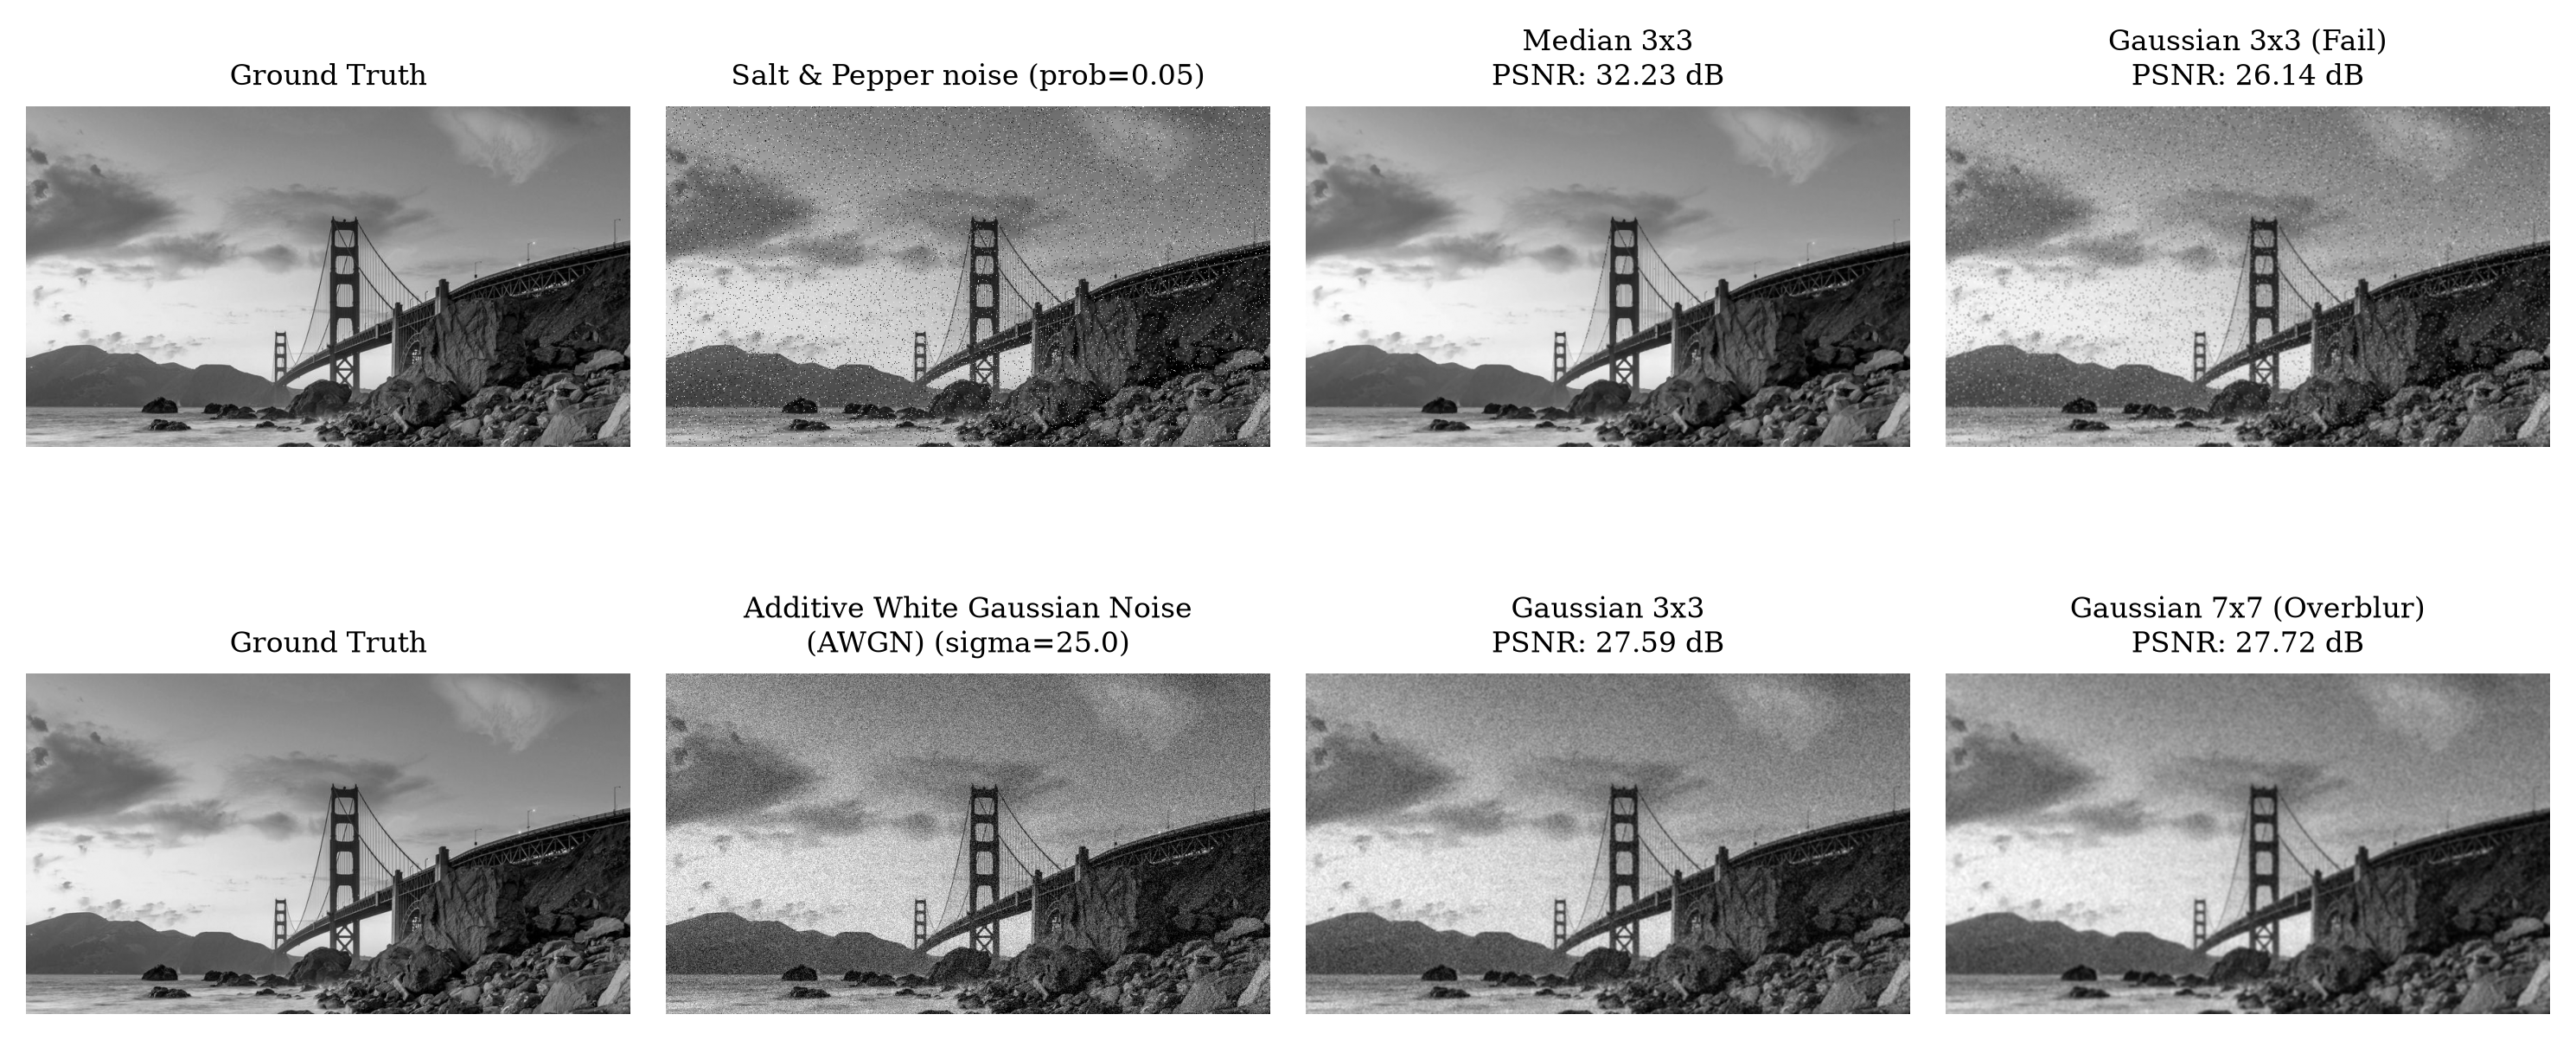

[2026-08-16 14:22:28,124] - INFO - Image berhasil di export...
[2026-08-16 14:22:28,124] - INFO - Image berhasil di export...


In [43]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))

# Row 1: Salt & Pepper
axes[0,0].imshow(original_img, cmap="gray")
axes[0,0].set_title("Ground Truth", fontsize=8)
axes[0,1].imshow(salt_pepper_noisy_img, cmap="gray")
axes[0,1].set_title("Salt & Pepper noise (prob=0.05)", fontsize=8)
axes[0,2].imshow(experiments[0]["image"], cmap="gray")
axes[0,2].set_title(f"Median 3x3\nPSNR: {experiments[0]["psnr"]} dB", fontsize=8)
axes[0,3].imshow(experiments[6]["image"], cmap='gray')
axes[0,3].set_title(f"Gaussian 3x3 (Fail)\nPSNR: {experiments[6]['psnr']} dB", fontsize=8)

# Row 2: Gaussian
axes[1,0].imshow(original_img, cmap="gray")
axes[1,0].set_title("Ground Truth", fontsize=8)
axes[1,1].imshow(gaussian_noisy_img, cmap="gray")
axes[1,1].set_title("Additive White Gaussian Noise\n(AWGN) (sigma=25.0)", fontsize=8)
axes[1,2].imshow(experiments[3]["image"], cmap="gray")
axes[1,2].set_title(f"Gaussian 3x3\nPSNR: {experiments[3]["psnr"]} dB", fontsize=8)
axes[1,3].imshow(experiments[5]["image"], cmap='gray')
axes[1,3].set_title(f"Gaussian 7x7 (Overblur)\nPSNR: {experiments[5]['psnr']} dB", fontsize=8)

for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.savefig("../images/visual_comparison.png", bbox_inches="tight")
plt.show()
logger.info("Image berhasil di export...")